In [1]:
import pandas as pd
import xarray as xr
import rasterio as rio
import numpy as np
import rioxarray
from glob import glob
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
md_df = pd.read_csv('md_processing_decisions.csv').iloc[:, 0:9]
md_df['survey_name'] = md_df['survey_name'].str.strip()

In [ ]:
stats_list = []
for i, row in md_df.iterrows():
    print(row.survey_name)
    dam_stats = []
    dam_stats.append(row.survey_name)
    md_gdf = gpd.read_file(f'../mapping/polygons/{row.survey_name.strip()}_md.shp')
    try:
        moving_gdf = gpd.read_file(f'../mapping/polygons/{row.survey_name.strip()}_moving.shp')
    except:
        continue
    stable_gdf = gpd.read_file(f'../mapping/polygons/{row.survey_name.strip()}_stable.shp')
    stable_gdf = stable_gdf.to_crs(md_gdf.crs)
    asc_veloc_ds = xr.open_dataset(f'../dams/{row.survey_name.strip()}/{row.survey_name.strip()}_asc_median_velocity.tif').squeeze()
    des_veloc_ds = xr.open_dataset(f'../dams/{row.survey_name.strip()}/{row.survey_name.strip()}_des_median_velocity.tif').squeeze()
    ud_veloc_ds = xr.open_dataset(f'../dams/{row.survey_name.strip()}/{row.survey_name.strip()}_ud_median_velocity.tif').squeeze()
    ew_veloc_ds = xr.open_dataset(f'../dams/{row.survey_name.strip()}/{row.survey_name.strip()}_ew_median_velocity.tif').squeeze()

    veloc_dic = {'asc':asc_veloc_ds, 'des':des_veloc_ds, 'ud':ud_veloc_ds, 'ew':ew_veloc_ds}

    for veloc_type, veloc_ds in veloc_dic.items():
        veloc_moving_ds = veloc_ds.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs)
        veloc_stable_ds = veloc_ds.rio.clip(stable_gdf.geometry, crs=stable_gdf.crs)

        if veloc_type == 'asc' or veloc_type == 'des':
            dam_stats.append(np.abs(veloc_moving_ds.band_data).mean().item()*100)
            dam_stats.append(veloc_stable_ds.band_data.mean().item()*100)
            dam_stats.append(veloc_stable_ds.band_data.std().item()*100)
            dam_stats.append(np.abs(veloc_moving_ds.band_data).quantile(0.95).item()*100)
            #dam_stats.append(np.abs(veloc_stable_ds.band_data).quantile(0.95).item()*100)
        elif veloc_type == 'ud': 
            dam_stats.append(veloc_moving_ds.band_data.mean().item()*100)
            dam_stats.append(veloc_moving_ds.band_data.std().item()*100)
            dam_stats.append(veloc_stable_ds.band_data.mean().item()*100)
            dam_stats.append(veloc_stable_ds.band_data.std().item()*100)
            dam_stats.append(veloc_moving_ds.band_data.quantile(0.05).item()*100)
            #dam_stats.append(veloc_stable_ds.band_data.quantile(0.05).item()*100)
        else:
            dam_stats.append(np.abs(veloc_moving_ds.band_data).mean().item()*100)
            dam_stats.append(veloc_moving_ds.band_data.std().item()*100)
            dam_stats.append(veloc_stable_ds.band_data.mean().item()*100)
            dam_stats.append(veloc_stable_ds.band_data.std().item()*100)
            dam_stats.append(veloc_moving_ds.band_data.quantile(0.95).item()*100)
            #dam_stats.append(veloc_stable_ds.band_data.quantile(0.95).item()*100)

    stats_list.append(dam_stats)
            

In [6]:
moving_gdf.area.sum()

27174.57314396416

In [ ]:
for i, row in md_df.iterrows():
    print(row.survey_name)
    md_gdf = gpd.read_file(f'../mapping/polygons/{row.survey_name.strip()}_md.shp')
    try:
        moving_gdf = gpd.read_file(f'../mapping/polygons/{row.survey_name.strip()}_moving.shp')
        print(moving_gdf.area.sum())
    except:
        continue

In [62]:
# df = pd.DataFrame(
#     stats_list,
#     columns=['moraine_name', 'asc_stable_mean', 'asc_moving_mean', 'asc_moving_max', 'asc_stable_max', 'des_moving_mean', 'des_stable_mean', 'des_moving_max', 'des_stable_max', 'ud_moving_mean', 'ud_stable_mean', 'ud_moving_max', 'ud_stable_max', 'ew_moving_mean', 'ew_stable_mean', 'ew_moving_max', 'ew_stable_max']
# )

In [17]:
df = pd.DataFrame(
    stats_list,
    columns=['moraine_name', 'asc_moving_mean', 'asc_stable_mean', 'asc_stable_std', 'asc_moving_p95', 'des_moving_mean', 'des_stable_mean', 'des_stable_std', 'des_moving_p95', 'ud_moving_mean', 'ud_moving_std', 'ud_stable_mean', 'ud_stable_std', 'ud_moving_p95', 'ew_moving_mean', 'ew_moving_std', 'ew_stable_mean', 'ew_stable_std', 'ew_moving_p95']
)

In [21]:
# Compute R^2 relative to the 1:1 line
x = df.ew_moving_mean.values
y = -df.ud_moving_mean.values

y_pred = x                                # 1:1 line prediction
ss_res = np.sum((y - y_pred)**2)          # residual sum of squares
ss_tot = np.sum((y - np.mean(y))**2)      # total sum of squares
r2_1to1 = 1 - ss_res / ss_tot

In [22]:
r2_1to1

0.23729634530717503

Text(0.5, 0, 'Mean absolute horizontal velocity (cm/yr)')

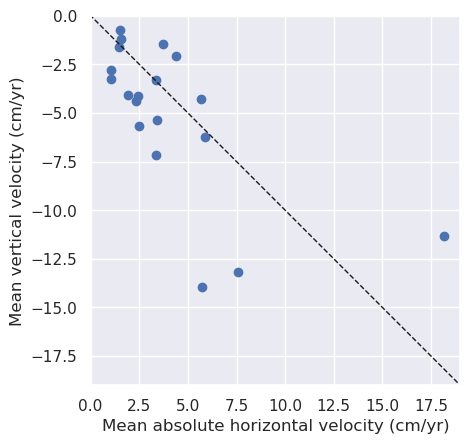

In [18]:
sns.set_theme()
f, ax = plt.subplots()
ax.plot([-2, 21], [2, -21], 'k--', lw=1, label='1:1 line')
ax.scatter(df.ew_moving_mean, df.ud_moving_mean)
ax.set_aspect('equal')
ax.set_xlim(0, 19)
ax.set_ylim(-19, 0)
ax.set_ylabel('Mean vertical velocity (cm/yr)')
ax.set_xlabel('Mean absolute horizontal velocity (cm/yr)')
#f.savefig('../manuscript_figs/ew_ud_velocity_scatter/ew_ud_velocity_scatter_v0.png', dpi=400, bbox_inches='tight')

In [10]:
df.ud_moving_p95.mean()

-12.56801613864745

In [28]:
df.ew_stable_std.mean()

0.5841099598212016

In [63]:
df.to_csv('md_velocity_stats.csv')

In [9]:
df.ud_stable_p95.mean()

AttributeError: 'DataFrame' object has no attribute 'ud_stable_p95'

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

stats_rows = []

component_map = {
    'asc': 'Asc LOS',
    'des': 'Des LOS',
    'ud':  'Up/Down',
    'ew':  'East/West',
}

for i, row in md_df.iterrows():
    print(row.survey_name)
    survey_name = row.survey_name.strip()

    # Read polygons
    md_gdf = gpd.read_file(
        f'../mapping/polygons/{survey_name}_md.shp'
    )
    try:
        moving_gdf = gpd.read_file(
            f'../mapping/polygons/{survey_name}_moving.shp'
        )
    except Exception:
        continue

    stable_gdf = gpd.read_file(
        f'../mapping/polygons/{survey_name}_stable.shp'
    )
    stable_gdf = stable_gdf.to_crs(md_gdf.crs)

    # Read velocity rasters
    asc_veloc_ds = xr.open_dataset(
        f'../dams/{survey_name}/{survey_name}_asc_median_velocity.tif'
    ).squeeze()
    des_veloc_ds = xr.open_dataset(
        f'../dams/{survey_name}/{survey_name}_des_median_velocity.tif'
    ).squeeze()
    ud_veloc_ds = xr.open_dataset(
        f'../dams/{survey_name}/{survey_name}_ud_median_velocity.tif'
    ).squeeze()
    ew_veloc_ds = xr.open_dataset(
        f'../dams/{survey_name}/{survey_name}_ew_median_velocity.tif'
    ).squeeze()

    veloc_dic = {
        'asc': asc_veloc_ds,
        'des': des_veloc_ds,
        'ud':  ud_veloc_ds,
        'ew':  ew_veloc_ds,
    }

    for veloc_type, veloc_ds in veloc_dic.items():
        component_label = component_map[veloc_type]

        # Clip to moving and stable polygons
        veloc_moving_ds = veloc_ds.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs)
        veloc_stable_ds = veloc_ds.rio.clip(stable_gdf.geometry, crs=stable_gdf.crs)

        # Extract numpy arrays and flatten
        moving_vals = veloc_moving_ds.band_data.values.ravel()
        stable_vals = veloc_stable_ds.band_data.values.ravel()

        # Mask NaNs
        moving_vals_valid = moving_vals[np.isfinite(moving_vals)]
        stable_vals_valid = stable_vals[np.isfinite(stable_vals)]

        if moving_vals_valid.size == 0 or stable_vals_valid.size == 0:
            continue

        # ---------------------------
        # MOVING-AREA STATISTICS
        # ---------------------------
        # Mean signed velocity
        mean_v_moving = float(np.nanmean(moving_vals_valid))

        # Std dev of signed velocity
        std_v_moving = float(np.nanstd(moving_vals_valid))

        # 5th and 95th percentiles of signed velocity
        p5_v_moving = float(np.nanpercentile(moving_vals_valid, 5))
        p95_v_moving = float(np.nanpercentile(moving_vals_valid, 95))

        # Mean absolute velocity
        mean_abs_v_moving = float(np.nanmean(np.abs(moving_vals_valid)))

        # Directional coherence
        pos = moving_vals_valid > 0
        neg = moving_vals_valid < 0
        n_pos = int(pos.sum())
        n_neg = int(neg.sum())
        n_dir_valid = n_pos + n_neg

        if n_dir_valid > 0:
            f_major = max(n_pos, n_neg) / n_dir_valid
        else:
            f_major = np.nan

        # Primary movement direction (per component)
        # Threshold for "mixed" based on coherence
        coherence_thresh = 0.6

        if (n_dir_valid == 0) or np.isnan(f_major) or (f_major < coherence_thresh):
            primary_dir = 'Mixed'
        else:
            if component_label == 'East/West':
                primary_dir = 'East' if mean_v_moving > 0 else 'West'
            elif component_label == 'Up/Down':
                primary_dir = 'Uplift' if mean_v_moving > 0 else 'Subsidence'
            else:
                # For LOS components if you ever inspect them
                primary_dir = 'Positive' if mean_v_moving > 0 else 'Negative'

        # ---------------------------
        # STABLE-AREA STATISTICS
        # ---------------------------
        mean_v_stable = float(np.nanmean(stable_vals_valid))
        std_v_stable = float(np.nanstd(stable_vals_valid))

        # Scale (e.g., m/yr → cm/yr)
        scale = 100.0
        mean_v_moving   *= scale
        std_v_moving    *= scale
        p5_v_moving     *= scale
        p95_v_moving    *= scale
        mean_abs_v_moving *= scale
        mean_v_stable   *= scale
        std_v_stable    *= scale

        stats_rows.append({
            'moraine_name':     survey_name,
            'component':        component_label,
            'primary_dir':      primary_dir,
            'f_major':          f_major,
            'mean_v_moving':    mean_v_moving,
            'std_v_moving':     std_v_moving,
            'p5_v_moving':      p5_v_moving,
            'p95_v_moving':     p95_v_moving,
            'mean_abs_v_moving': mean_abs_v_moving,
            'mean_v_stable':    mean_v_stable,
            'std_v_stable':     std_v_stable,
        })

# Long-format DataFrame
df_long = pd.DataFrame(stats_rows)

# ---------------------------
# WIDE-FORMAT TABLE FOR Up/Down AND East/West
# ---------------------------

# Keep only vertical and east–west components
ud_ew = df_long[df_long['component'].isin(['Up/Down', 'East/West'])].copy()

# Pivot to wide format
wide = ud_ew.pivot(
    index='moraine_name',
    columns='component',
    values=[
        'primary_dir',
        'f_major',
        'mean_v_moving',
        'std_v_moving',
        'p5_v_moving',
        'p95_v_moving',
        'mean_abs_v_moving',
        'mean_v_stable',
        'std_v_stable',
    ],
)

# Flatten MultiIndex columns
wide.columns = [f"{metric} {comp}" for metric, comp in wide.columns]

# Human-readable column names
rename_map = {
    # Up/Down
    'primary_dir Up/Down':         'Primary vertical movement direction',
    'f_major Up/Down':             'Directional coherence (vertical)',
    'mean_v_moving Up/Down':       'Mean vertical velocity (cm yr^-1)',
    'std_v_moving Up/Down':        'Std dev vertical velocity (cm yr^-1)',
    'p5_v_moving Up/Down':         '5th percentile vertical velocity (cm yr^-1)',
    'p95_v_moving Up/Down':        '95th percentile vertical velocity (cm yr^-1)',
    'mean_abs_v_moving Up/Down':   'Mean |vertical velocity| (cm yr^-1)',
    'mean_v_stable Up/Down':       'Stable-area mean vertical velocity (cm yr^-1)',
    'std_v_stable Up/Down':        'Stable-area std dev vertical velocity (cm yr^-1)',

    # East/West
    'primary_dir East/West':       'Primary east–west movement direction',
    'f_major East/West':           'Directional coherence (east–west)',
    'mean_v_moving East/West':     'Mean east–west velocity (cm yr^-1)',
    'std_v_moving East/West':      'Std dev east–west velocity (cm yr^-1)',
    'p5_v_moving East/West':       '5th percentile east–west velocity (cm yr^-1)',
    'p95_v_moving East/West':      '95th percentile east–west velocity (cm yr^-1)',
    'mean_abs_v_moving East/West': 'Mean |east–west velocity| (cm yr^-1)',
    'mean_v_stable East/West':     'Stable-area mean east–west velocity (cm yr^-1)',
    'std_v_stable East/West':      'Stable-area std dev east–west velocity (cm yr^-1)',
}

wide = wide.rename(columns=rename_map)

# Order columns in logical groups
col_order = [
    # Vertical
    'Primary vertical movement direction',
    'Directional coherence (vertical)',
    'Mean vertical velocity (cm yr^-1)',
    'Std dev vertical velocity (cm yr^-1)',
    '5th percentile vertical velocity (cm yr^-1)',
    '95th percentile vertical velocity (cm yr^-1)',
    'Mean |vertical velocity| (cm yr^-1)',
    'Stable-area mean vertical velocity (cm yr^-1)',
    'Stable-area std dev vertical velocity (cm yr^-1)',

    # East–West
    'Primary east–west movement direction',
    'Directional coherence (east–west)',
    'Mean east–west velocity (cm yr^-1)',
    'Std dev east–west velocity (cm yr^-1)',
    '5th percentile east–west velocity (cm yr^-1)',
    '95th percentile east–west velocity (cm yr^-1)',
    'Mean |east–west velocity| (cm yr^-1)',
    'Stable-area mean east–west velocity (cm yr^-1)',
    'Stable-area std dev east–west velocity (cm yr^-1)',
]

wide = wide[col_order].reset_index()

# Ensure rows appear in the original md_df order
wide['moraine_name'] = pd.Categorical(
    wide['moraine_name'],
    categories=md_df['survey_name'].str.strip(),
    ordered=True
)

wide = wide.sort_values('moraine_name').reset_index(drop=True)

wide.to_csv('md_velocity_stats_ud_ew_wide.csv', index=False)

In [9]:
import pandas as pd

# Filter to Asc/Des LOS components from df_long
los = df_long[df_long['component'].isin(['Asc LOS', 'Des LOS'])].copy()

# Pivot to wide format
los_wide = los.pivot(
    index='moraine_name',
    columns='component',
    values=[
        'primary_dir',
        'f_major',
        'mean_v_moving',
        'std_v_moving',
        'p5_v_moving',
        'p95_v_moving',
        'mean_abs_v_moving',
        'mean_v_stable',
        'std_v_stable',
    ],
)

# Flatten MultiIndex columns
los_wide.columns = [f"{metric} {comp}" for metric, comp in los_wide.columns]

# Human-readable column names
los_rename_map = {
    # Asc LOS
    'primary_dir Asc LOS':         'Primary Asc LOS movement direction',
    'f_major Asc LOS':             'Directional coherence (Asc LOS)',
    'mean_v_moving Asc LOS':       'Mean Asc LOS velocity (cm yr^-1)',
    'std_v_moving Asc LOS':        'Std dev Asc LOS velocity (cm yr^-1)',
    'p5_v_moving Asc LOS':         '5th percentile Asc LOS velocity (cm yr^-1)',
    'p95_v_moving Asc LOS':        '95th percentile Asc LOS velocity (cm yr^-1)',
    'mean_abs_v_moving Asc LOS':   'Mean |Asc LOS velocity| (cm yr^-1)',
    'mean_v_stable Asc LOS':       'Stable-area mean Asc LOS velocity (cm yr^-1)',
    'std_v_stable Asc LOS':        'Stable-area std dev Asc LOS velocity (cm yr^-1)',

    # Des LOS
    'primary_dir Des LOS':         'Primary Des LOS movement direction',
    'f_major Des LOS':             'Directional coherence (Des LOS)',
    'mean_v_moving Des LOS':       'Mean Des LOS velocity (cm yr^-1)',
    'std_v_moving Des LOS':        'Std dev Des LOS velocity (cm yr^-1)',
    'p5_v_moving Des LOS':         '5th percentile Des LOS velocity (cm yr^-1)',
    'p95_v_moving Des LOS':        '95th percentile Des LOS velocity (cm yr^-1)',
    'mean_abs_v_moving Des LOS':   'Mean |Des LOS velocity| (cm yr^-1)',
    'mean_v_stable Des LOS':       'Stable-area mean Des LOS velocity (cm yr^-1)',
    'std_v_stable Des LOS':        'Stable-area std dev Des LOS velocity (cm yr^-1)',
}

los_wide = los_wide.rename(columns=los_rename_map)

# Column order: Asc first, then Des, in logical groups
los_col_order = [
    # Asc LOS
    'Primary Asc LOS movement direction',
    'Directional coherence (Asc LOS)',
    'Mean Asc LOS velocity (cm yr^-1)',
    'Std dev Asc LOS velocity (cm yr^-1)',
    '5th percentile Asc LOS velocity (cm yr^-1)',
    '95th percentile Asc LOS velocity (cm yr^-1)',
    'Mean |Asc LOS velocity| (cm yr^-1)',
    'Stable-area mean Asc LOS velocity (cm yr^-1)',
    'Stable-area std dev Asc LOS velocity (cm yr^-1)',

    # Des LOS
    'Primary Des LOS movement direction',
    'Directional coherence (Des LOS)',
    'Mean Des LOS velocity (cm yr^-1)',
    'Std dev Des LOS velocity (cm yr^-1)',
    '5th percentile Des LOS velocity (cm yr^-1)',
    '95th percentile Des LOS velocity (cm yr^-1)',
    'Mean |Des LOS velocity| (cm yr^-1)',
    'Stable-area mean Des LOS velocity (cm yr^-1)',
    'Stable-area std dev Des LOS velocity (cm yr^-1)',
]

los_wide = los_wide[los_col_order].reset_index()

# Preserve original md_df order for rows
los_wide['moraine_name'] = pd.Categorical(
    los_wide['moraine_name'],
    categories=md_df['survey_name'].str.strip(),
    ordered=True
)
los_wide = los_wide.sort_values('moraine_name').reset_index(drop=True)

#los_wide.to_csv('md_velocity_stats_los_wide.csv', index=False)


In [17]:
los_wide['Stable-area std dev Des LOS velocity (cm yr^-1)'].mean()

0.4825327733566184

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns


dam_names = []
ew_moving_list = [] 
ud_moving_list = [] # list of 1D arrays (moving area velocities)
ew_stable_list = []   # list of 1D arrays (stable area velocities)

for i, row in md_df.iterrows():
    survey_name = row.survey_name.strip()
    print(survey_name)

    # Read polygons
    try:
        moving_gdf = gpd.read_file(
            f'../mapping/polygons/{survey_name}_moving.shp'
        )
    except Exception:
        # no moving polygon → skip
        continue

    stable_gdf = gpd.read_file(
        f'../mapping/polygons/{survey_name}_stable.shp'
    )

    # Make sure CRSs match
    stable_gdf = stable_gdf.to_crs(moving_gdf.crs)

    # Read east–west velocity raster
    ew_veloc_ds = xr.open_dataset(
        f'../dams/{survey_name}/{survey_name}_ew_median_velocity.tif'
    ).squeeze()

    # Read ud velocity raster
    ud_veloc_ds = xr.open_dataset(
        f'../dams/{survey_name}/{survey_name}_ud_median_velocity.tif'
    ).squeeze()

    # Clip to moving and stable polygons
    ew_moving_ds = ew_veloc_ds.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs)
    ud_moving_ds = ud_veloc_ds.rio.clip(moving_gdf.geometry, crs=moving_gdf.crs)
    ew_stable_ds = ew_veloc_ds.rio.clip(stable_gdf.geometry, crs=stable_gdf.crs)

    # Extract values, flatten, and drop NaNs
    moving_vals = ew_moving_ds.band_data.values.ravel()
    ud_moving_vals = ud_moving_ds.band_data.values.ravel()
    stable_vals = ew_stable_ds.band_data.values.ravel()

    moving_vals_valid = moving_vals[np.isfinite(moving_vals)]
    ud_moving_vals_valid = ud_moving_vals[np.isfinite(moving_vals)]
    stable_vals_valid = stable_vals[np.isfinite(stable_vals)]

    if moving_vals_valid.size == 0 or stable_vals_valid.size == 0:
        continue

    # Optional: convert from m/yr to cm/yr
    scale = 100.0
    moving_vals_valid = moving_vals_valid * scale
    ud_moving_vals_valid = ud_moving_vals_valid * scale
    stable_vals_valid = stable_vals_valid * scale

    dam_names.append(survey_name)
    ew_moving_list.append(moving_vals_valid)
    ud_moving_list.append(ud_moving_vals_valid)
    ew_stable_list.append(stable_vals_valid)

    ud_medians = np.array([np.nanmedian(arr) for arr in ud_moving_list])
    
    # Get indices that would sort by median (ascending)
    order = np.argsort(ud_medians)  # use [::-1] for descending
    
    # Reorder everything consistently
    dam_names        = [dam_names[i] for i in order]
    ud_moving_list = [ud_moving_list[i] for i in order]
    ew_moving_list   = [ew_moving_list[i] for i in order]
    ew_stable_list   = [ew_stable_list[i] for i in order]

# --------------------
# Paired boxplot figure
# --------------------

n_dams = len(dam_names)
x_base = np.arange(n_dams)  # one x position per dam
offset = 0.2

In [11]:
order

array([ 1,  2,  5,  3, 10,  8, 18, 12,  4,  9,  6, 14, 17,  7, 13, 11, 15,
        0, 16])

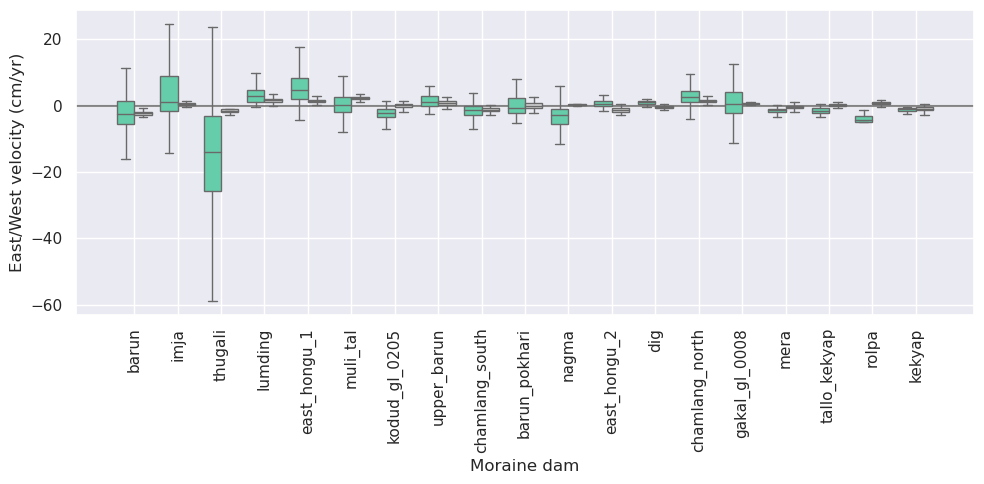

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
sns.set_theme()

n_dams = len(dam_names)
x_base = np.arange(n_dams)       # one x position per dam
offset = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, c='k', alpha=0.5)

# Boxplots for moving areas (GREEN)
bp_moving = ax.boxplot(
    ew_moving_list,
    positions=x_base - offset,
    widths=0.4,
    patch_artist=True,
    manage_ticks=False,
    showfliers=False,     # HIDE FLIERS
    boxprops=dict(facecolor='mediumaquamarine',  color='dimgray'),
    capprops=dict(color='dimgray'),
    whiskerprops=dict(color='dimgray'),
    medianprops=dict(color='dimgray'),
)

# Boxplots for stable areas (GRAY)
bp_stable = ax.boxplot(
    ew_stable_list,
    positions=x_base + offset,
    widths=0.4,
    patch_artist=True,
    manage_ticks=False,
    showfliers=False,     # HIDE FLIERS
    boxprops=dict(facecolor='lightgray', color='dimgray'),
    capprops=dict(color='dimgray'),
    whiskerprops=dict(color='dimgray'),
    medianprops=dict(color='dimgray'),
)

# X-axis labels: center on dam names
ax.set_xticks(x_base)
ax.set_xticklabels(dam_names, rotation=90)

ax.set_xlabel('Moraine dam')
ax.set_ylabel('East/West velocity (cm/yr)')

# Legend using color patches
legend_handles = [
    Patch(facecolor='mediumaquamarine',     edgecolor='dimgray', label='Moving area'),
    Patch(facecolor='lightgray', edgecolor='dimgray', label='Stable area'),
]
#ax.legend(handles=legend_handles, loc='best')

fig.tight_layout()
fig.savefig('../manuscript_figs/ew_velocity_maps/v2/ew_boxplots.png', dpi=400, bbox_inches='tight')

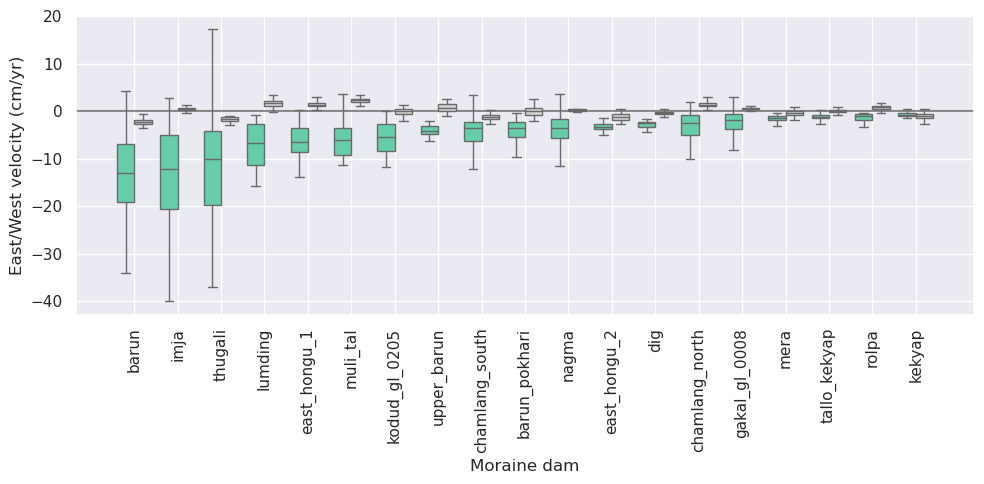

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
sns.set_theme()

n_dams = len(dam_names)
x_base = np.arange(n_dams)       # one x position per dam
offset = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
ax.axhline(0, c='k', alpha=0.5)

# Boxplots for moving areas (GREEN)
bp_moving = ax.boxplot(
    ud_moving_list,
    positions=x_base - offset,
    widths=0.4,
    patch_artist=True,
    manage_ticks=False,
    showfliers=False,     # HIDE FLIERS
    boxprops=dict(facecolor='mediumaquamarine',  color='dimgray'),
    capprops=dict(color='dimgray'),
    whiskerprops=dict(color='dimgray'),
    medianprops=dict(color='dimgray'),
)

# Boxplots for stable areas (GRAY)
bp_stable = ax.boxplot(
    ew_stable_list,
    positions=x_base + offset,
    widths=0.4,
    patch_artist=True,
    manage_ticks=False,
    showfliers=False,     # HIDE FLIERS
    boxprops=dict(facecolor='lightgray', color='dimgray'),
    capprops=dict(color='dimgray'),
    whiskerprops=dict(color='dimgray'),
    medianprops=dict(color='dimgray'),
)

# X-axis labels: center on dam names
ax.set_xticks(x_base)
ax.set_xticklabels(dam_names, rotation=90)

ax.set_xlabel('Moraine dam')
ax.set_ylabel('East/West velocity (cm/yr)')

# Legend using color patches
legend_handles = [
    Patch(facecolor='mediumaquamarine',     edgecolor='dimgray', label='Moving area'),
    Patch(facecolor='lightgray', edgecolor='dimgray', label='Stable area'),
]
#ax.legend(handles=legend_handles, loc='best')

fig.tight_layout()
#fig.savefig('../manuscript_figs/ew_velocity_maps/v2/ew_boxplots.png', dpi=400, bbox_inches='tight')